# Purpose of Script

Perform exploratory analysis of electronic health records investigating relationships between cardiac events and flu cases. A client suspects that there is a relationship, and has provided data for us to explore and model.

### Before the analysis begins:
Familiarize yourself with the problem, current research, and define the exact needs from the stake holder.

* Heart attacks (Myocardial infarction):
    * 805,000 per year in U.S. ([CDC](https://www.cdc.gov/heart-disease/data-research/facts-stats/index.html))
    * Signficant sex and racial differences ([CDC](https://www.cdc.gov/heart-disease/data-research/facts-stats/index.html))

* Ischemic Strokes
    * Nearly 700,00 ischemic strokes per in U.S. ([CDC](https://www.cdc.gov/stroke/data-research/facts-stats/?ref=greatspeech.com))
    * One of the leading causes of disability in the U.S. ([NIH](https://www.nichd.nih.gov/health/topics/stroke/conditioninfo/risk))

* Influenza:
    * Between 9.4 - 51 Million cases per year in the U.S. ([CDC](https://www.cdc.gov/flu-burden/php/about/index.html))

---

### Pre-existing literature on potential relationships:

1. Effect of Influenza Vaccination on Major Cardiovascular Events and Mortality: A Systematic Review and Meta-Analysis of Randomized Controlled Trials ([September 2026](https://pubmed.ncbi.nlm.nih.gov/42720234/$0))
    * **"Influenza vaccination significantly reduced major adverse cardiovascular events and cardiovascular mortality.** 

2. Influenza vaccination associates with reduced risk of incident ischemic stroke among older adults with diabetes: A population-based retrospective cohort study ([July 2026](https://pmc.ncbi.nlm.nih.gov/articles/PMC13432903/$0)).
    * "Seasonal **influenza vaccination was associated with a significantly reduced risk of incident IS** within 7 months among older adults with diabetes"

## Data Selection

The [Synthetic Patient Data in OMOP](https://console.cloud.google.com/marketplace/product/hhs/synpuf?project=project-d60bc1f8-9487-4a43-958) was chosen based on the size of the data, and the accessibility through Google BigQuery. 

* Basics: 
    * Synthetic Medicare Claims from 2008 - 2010
    * 2.4 million records
    * Spans 24 OMOP tables

## Methodology

* Data was queried using SQL through the BigQuery API Endpoint. The following concepts were the focus of the queries:
    * Influenza cases
    * Influenza vaccination
    * Cardiac events 
        * Defined by heart attack and stroke
    

The National Cancer Institute provides a very intuitive [search engine](https://evsexplore.semantics.cancer.gov/) to find concept identifiers for vocabularies such as SNOMED.

* Descriptive analyses were performed via Python



<!-- SNOMED codes were obtained using this [search engine]().

To assess the relationship between influenza and cardiac events, the following 'general' concepts were used:
* Influenza|
* Myocardial Infarction (Heart attack)
* Cerebroaccidents (Strokes)
* Influenza vaccination -->

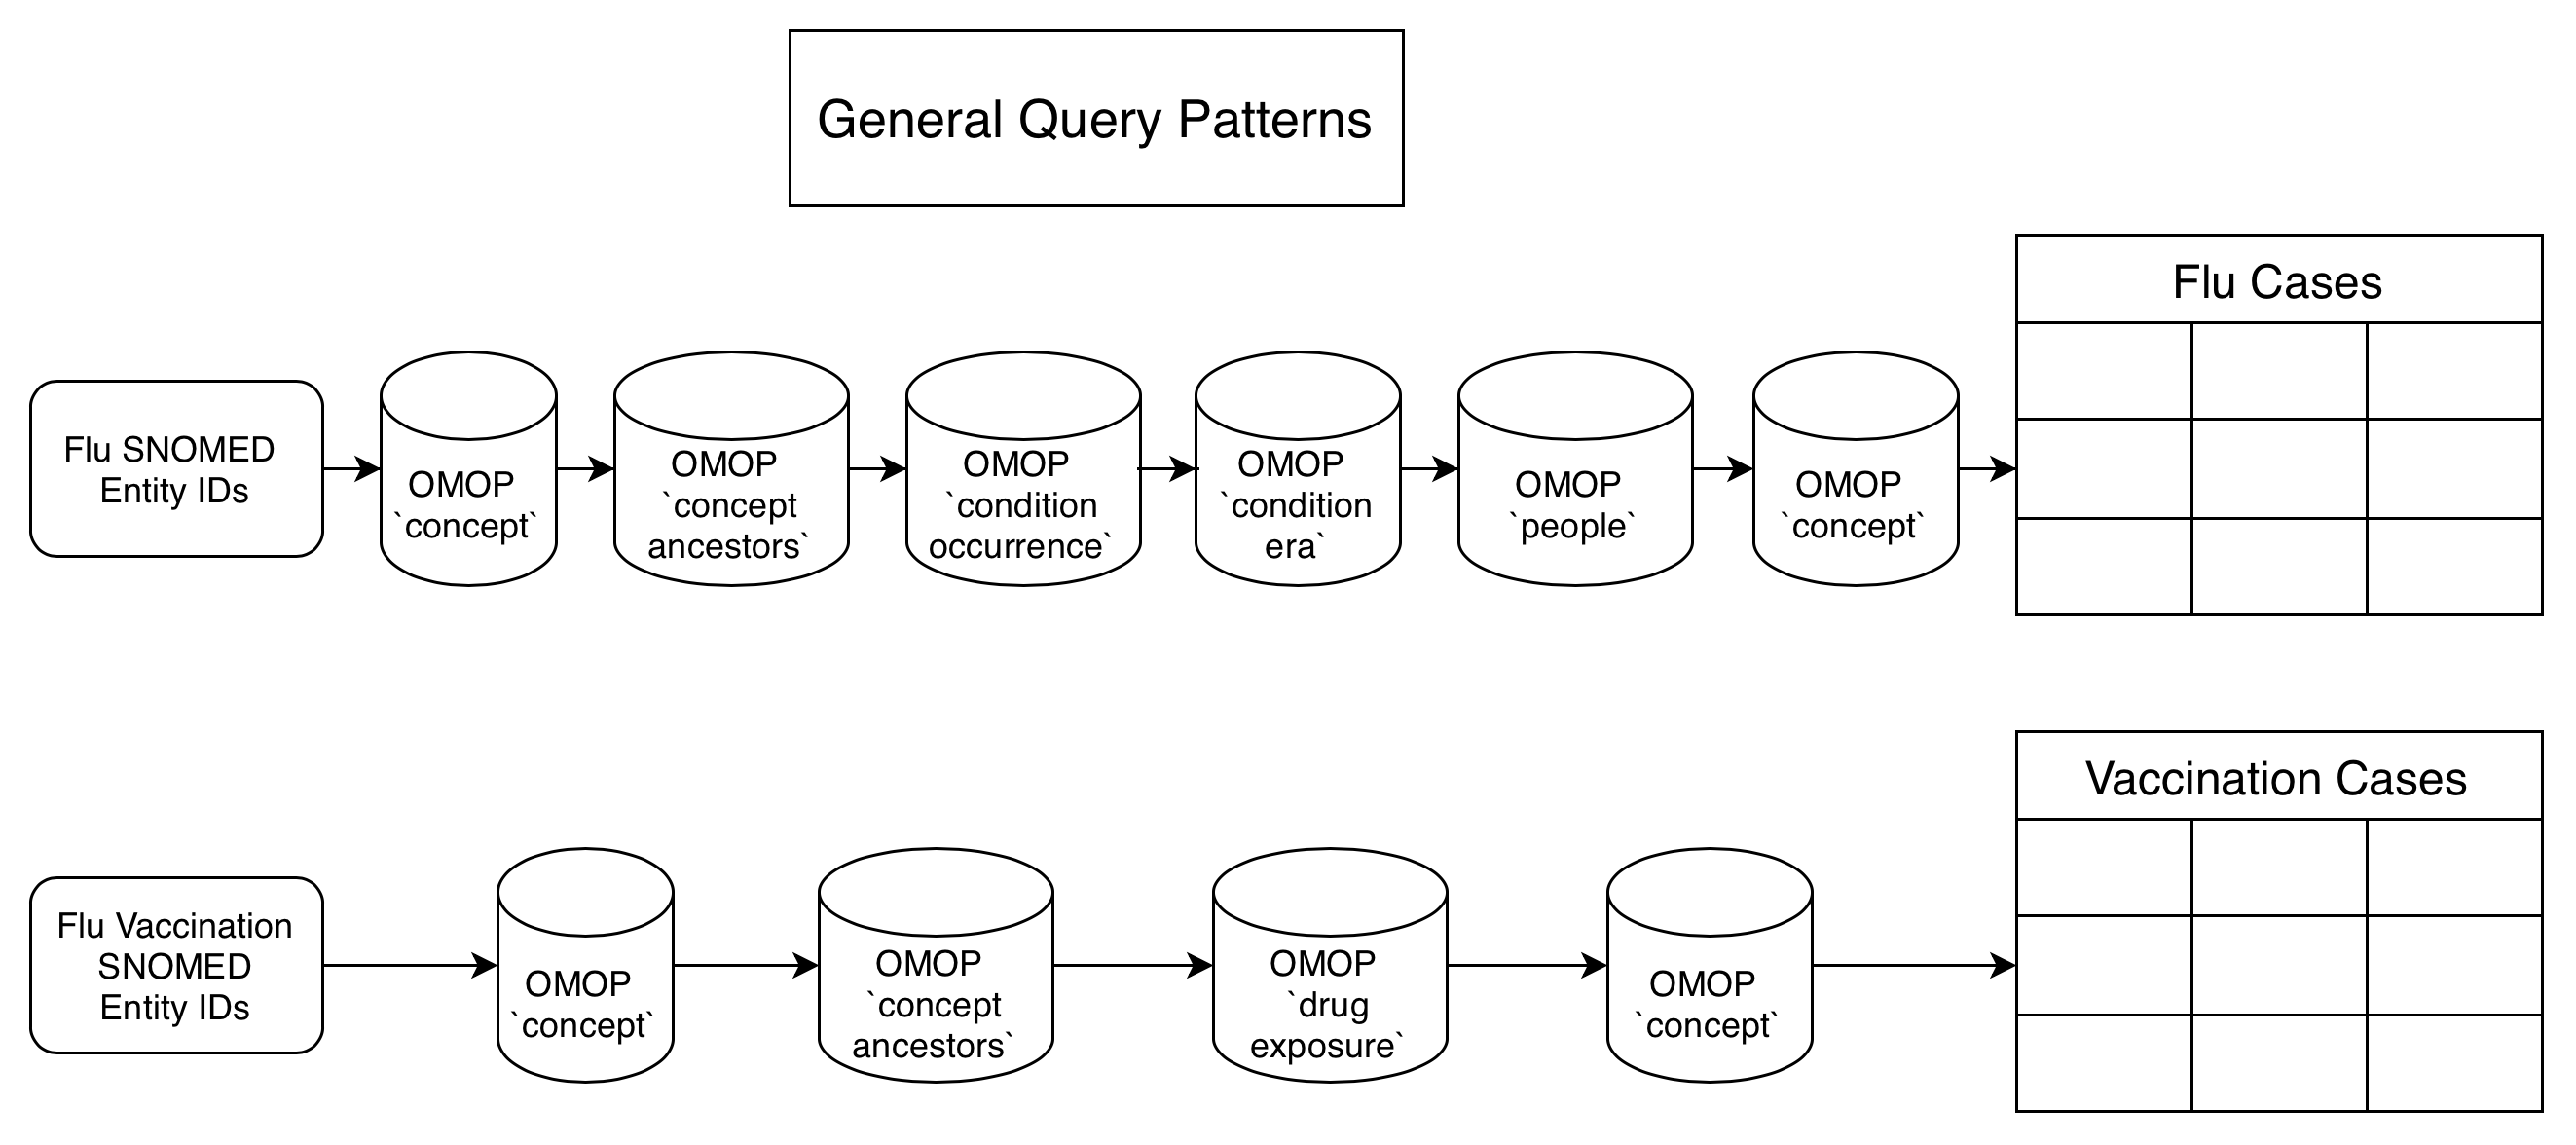

In [1]:
from IPython.display import Image, Markdown

Image(filename='images/query_steps.png') 

### Example of Concept and Descendents in SNOMED Vocabulary

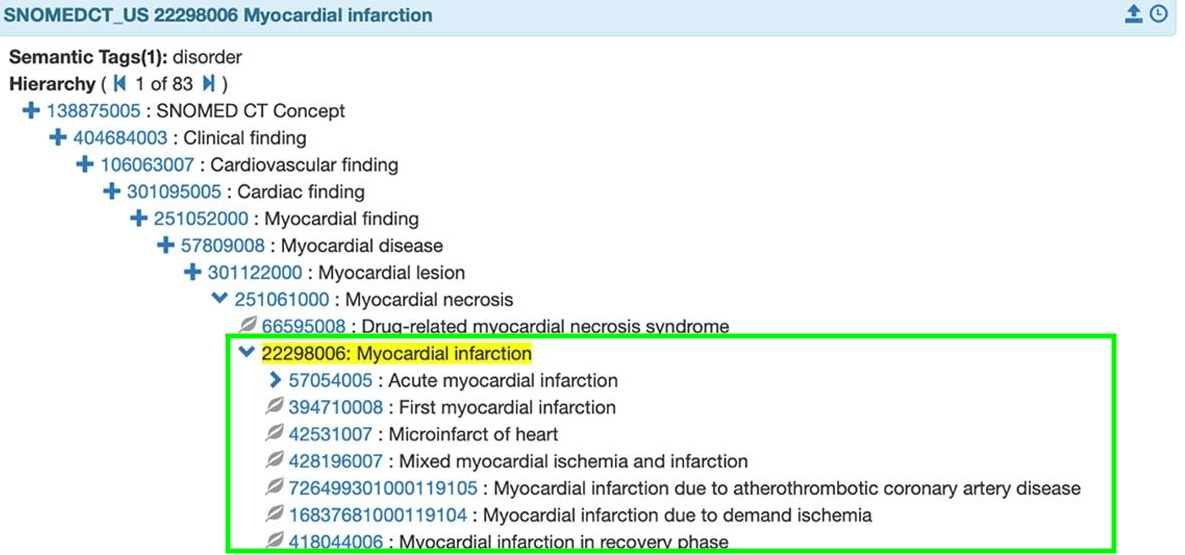

In [2]:
# from IPython.display import Image

display(Markdown("### Example of Concept and Descendents in SNOMED Vocabulary"))
Image(filename='images/snomed_example.jpg') 

### Things to look out for:

* Duplicates (1-2% of EHR data are historically duplicate information)
* Repeated entries with varying granularity of condition or treatment (parent - child - sibling)

In [3]:
## import statements
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

plt.style.use("ggplot")

from google.cloud import bigquery
from IPython.display import Image, Markdown

CLIENT = bigquery.Client(project="project-d60bc1f8-9487-4a43-958")
# https://docs.cloud.google.com/bigquery/docs/python-libraries?hl=en&utm_source=chatgpt.com#google-cloud-bigquery

In [4]:
## define SNOMED codes - from search engine
cardiac_concept_codes = {
    'cerebro_accident': '230690007',
    'myocardial_infarction': '22298006'
                        }

flu_concept_codes = {
    'general_flu' : "6142004",
    'flu_virus' : "725894000",
    'flu_b' :  "24662006",
    'flu_a' :"442438000",
    'seasonal_flu' : "719590007",
    'pandemic_flu' : "719865001",
    'flu_c' : "81524006"
                    }

## RXNorm may have been better (12916963) - keep for now
vaccine_concept_codes = {
    'flu_vaccine_1': "placeholder", ## need two elements in dict
    'flu_vaccine_2': '86198006'
                         }

### Functions to Query Database

Functions to call GCP for OMOP data.

In [5]:
def get_total_cases(concept_codes_dict: dict, cleanup_empty_cols: bool = True) -> pd.DataFrame:
    """
    Obtain every claim related to the diagnosis of provided concept code(s). Will 
    contain duplicate data / records, based on multiple entries  per visit, multiple visits 
    per case, etc.

    Args: concept_codes_dict - dictionary containing key value pairs, where the key
        is a basic identifier of what the code (provided as the dictionary value) 
        represents.
        cleanup_empty_cols: bool - indicates whether columns entirely null are dropped

    Returns:
        pd.DataFrame of data for respective concepts. 
    """

    query = f"""

        -- get the OMOP identifier from the source vocabulary ID
        WITH top_level AS (
         SELECT `concept_id` AS `ancestor_concept_id`, 
                `concept_name` AS `ancestor_concept`,
                `concept_code` AS `concept_search_code`
                    FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
                    WHERE `concept_code` IN {tuple(concept_codes_dict.values())}
        ),

        -- take any child diagnoses underneath the high level term
        disease_subtypes AS 
        ( 
            SELECT *
            FROM top_level t 
            JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor` ca 
            ON t.`ancestor_concept_id` = ca.`ancestor_concept_id`
            WHERE 1 = 1
        ),

        -- actual times the disease is diagnosed (careful for duplicate records)
        disease_happened as 
        (
            SELECT *,
                EXTRACT(MONTH FROM `condition_start_date`) AS condition_start_date_month,
                EXTRACT(YEAR FROM `condition_start_date`) AS condition_start_date_year
                    FROM disease_subtypes f
                    LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence` co
                    ON f.`descendant_concept_id` = co.`condition_concept_id`
        ),

        -- visits may be spread across PCP, specialists, follow ups for the same case
        grouping_visits as 
        (
            SELECT dh.*, co.`condition_era_id`, 
                    co.`condition_era_start_date`, 
                    co.`condition_era_end_date`,
                    co.`condition_occurrence_count` 
            FROM disease_happened dh
                LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.condition_era` co
                ON co.condition_concept_id = dh.condition_concept_id 
                AND co.`person_id` = dh.`person_id`
        ),

        -- background on patients
        people_background as 
        (
            SELECT *, `condition_start_date_year` - `year_of_birth` AS `age_at_diagnosis`
                FROM grouping_visits dh
                JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.person` p
                USING(`person_id`)
        ),

        -- string labels for gender - not just codes
        gender_labeled as 
        (
            SELECT pb.*, con.`concept_name` AS `gender_label`
            FROM people_background pb
            LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
            ON pb.`gender_concept_id` = con.`concept_id`
        ),

        -- string labels for ethnicity - not just codes
        ethnicity_labeled as 
        (
            SELECT gl.*, con.`concept_name` AS `ethnicity_label`
            FROM gender_labeled gl
            LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
            ON gl.`ethnicity_concept_id` = con.`concept_id`
        ),

        -- labels for diagnosis - not just codes
        diagnosis_labeled as 
        (
            SELECT el.*, con.`concept_name` as `condition_label`,
            FROM ethnicity_labeled el
            LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
            ON el.`condition_concept_id` = con.`concept_id`
        )

        SELECT *
            FROM diagnosis_labeled
        """

    disease_df = CLIENT.query(query).to_dataframe()

    if cleanup_empty_cols:
        disease_df = disease_df.dropna(axis=1)
        
    ## preview
    print(f"Number of records: {len(disease_df):,}")
    print(f"Number of unique patients: {len(disease_df['person_id'].unique()):,}\n")

    display(disease_df.head())

    return disease_df

In [6]:
def get_drug_treatments(concept_codes_dict: dict, cleanup_empty_cols: bool = True) -> pd.DataFrame:
    """
    Using the provided concept codes, search for records of administering
    a drug to patients.
    
    Args:
        concept_codes_dict: dict containing the codes for the drug treatment (i.e. flu vaccine)
        cleanup_empty_cols: bool - indicates whether columns entirely null are dropped

    Returns:
        df: pd.DataFrame containing records of drug administration. 
    """

    query = f"""

        -- take any diagnoses underneath the high level term
        WITH disease_subtypes AS
            ( 
            SELECT *
                FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
                WHERE 1 = 1
                AND `ancestor_concept_id` IN (
                SELECT `concept_id`
                    FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
                    WHERE `concept_code` IN {tuple(concept_codes_dict.values())}
                )
            ),

        -- exposure and administration of subtypes
        with_administration AS 
            (
            SELECT *
                FROM `bigquery-public-data.cms_synthetic_patient_data_omop.drug_exposure`
                WHERE 1 = 1
                AND `drug_concept_id` IN 
                (
                SELECT `descendant_concept_id`
                    from disease_subtypes
                )
            ),

        -- actual name of vaccine
        vaccine_labeled AS
            (
            select wd.*, con.`concept_name` AS `vaccine_label`
                FROM with_administration wd
                LEFT JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.concept` con
                ON wd.`drug_concept_id` = con.`concept_id`
            )

    SELECT * 
        FROM vaccine_labeled
    """

    df = CLIENT.query(query).to_dataframe()

    if cleanup_empty_cols:
        df = df.dropna(axis=1)

    ## preview
    print(f"Number of records: {len(df):,}")
    print(f"Number of unique patients: {len(df['person_id'].unique()):,}\n")
    display(df.head())

    return df

### Data Query: Vaccine Administration

In [7]:
flu_vaccine_df = get_drug_treatments(vaccine_concept_codes)

Number of records: 1,708,934
Number of unique patients: 977,094



,drug_type_concept_id,visit_occurrence_id,drug_source_value,drug_source_concept_id,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_end_date,vaccine_label
0,38000175,59246471,90660,2213442,66911268,1235100,2213442,2009-04-04,2009-05-04,"Influenza virus vaccine, trivalent, live (LAIV..."
1,38000175,29575353,90660,2213442,33404064,616749,2213442,2008-08-05,2008-09-04,"Influenza virus vaccine, trivalent, live (LAIV..."
2,38000175,110084547,90660,2213442,124303812,2294450,2213442,2008-09-27,2008-10-27,"Influenza virus vaccine, trivalent, live (LAIV..."
3,38000175,53007696,90660,2213442,59914468,1105355,2213442,2008-11-03,2008-12-03,"Influenza virus vaccine, trivalent, live (LAIV..."
4,38000175,95262399,90660,2213442,107570710,1985777,2213442,2008-11-06,2008-12-06,"Influenza virus vaccine, trivalent, live (LAIV..."


In [8]:
## calculate length of drug - exposure. Curious why not single day
flu_vaccine_df['vaccine_exposure_length'] = flu_vaccine_df['drug_exposure_end_date'] - flu_vaccine_df['drug_exposure_start_date']
# flu_vaccine_df['vaccine_exposure_length_int'] = pd.to_timedelta(flu_vaccine_df['vaccine_exposure_length']).dt.days

display(pd.DataFrame(flu_vaccine_df['vaccine_exposure_length'].value_counts()))

,count
vaccine_exposure_length,
30 days,1708934


Interestingly, some of the drug-exposures have an end date. I would assume that flu vaccines would have the same start and end date. Looking at the data, seems like it is always one month exposure.

In [9]:
pd.DataFrame(flu_vaccine_df['vaccine_label'].value_counts())

,count
vaccine_label,
"Influenza virus vaccine, trivalent (IIV3), split virus, 0.5 mL dosage, for intramuscular use",1542698
"Influenza virus vaccine, trivalent (IIV3), split virus, preservative free, 0.5 mL dosage, for intramuscular use",139389
"Influenza virus vaccine (IIV), split virus, preservative free, enhanced immunogenicity via increased antigen content, for intramuscular use",21841
"Influenza virus vaccine, trivalent (IIV3), split virus, 0.25 mL dosage, for intramuscular use",3064
"Influenza virus vaccine, trivalent, live (LAIV3), for intranasal use",1448
"Influenza virus vaccine, trivalent (IIV3), split virus, preservative free, 0.25 mL dosage, for intramuscular use",384
"Influenza virus vaccine, trivalent (ccIIV3), derived from cell cultures, subunit, preservative and antibiotic free, 0.5 mL dosage, for intramuscular use",59
"Influenza virus vaccine (IIV), pandemic formulation, split virus, preservative free, for intramuscular use",20
"Influenza virus vaccine (IIV), pandemic formulation, split virus, for intramuscular use",18


### Duplicate Check - Vaccines

Multiple records exist for the same person - drug - and start date. For the flu vaccine, I would not expect this to be the case in the real world.

In [10]:
pd.DataFrame(flu_vaccine_df[['person_id', 'drug_concept_id', 'drug_exposure_start_date']].value_counts())

,,,count
person_id,drug_concept_id,drug_exposure_start_date,
1022242,2213440,2010-05-26,12
1798670,2213440,2010-02-21,12
948060,2213440,2008-08-30,11
1257144,2213440,2008-03-27,11
434178,2213440,2009-02-17,11
...,...,...,...
442787,2213440,2010-07-27,1
2286022,2213440,2010-07-27,1
1085195,2213440,2010-07-27,1


In [11]:
### 
duplicate_shots = len(flu_vaccine_df[flu_vaccine_df.duplicated(subset=['person_id', 'drug_exposure_start_date'])])
print(f"On {duplicate_shots:,} occasions, patients were 'administered' multiple flu shots on the same date.")

On 133,060 occasions, patients were 'administered' multiple flu shots on the same date.


One patient (person_id = 713423) was administered twice on the same day, where the only different value was the `drug_exposure_id` value.

To address this, the initial decision was to deduplicate based on the date of drug administration, with the understanding that this does not fully account for potentially erroneous / duplicate entries.

In [12]:
flu_vaccine_deduped = flu_vaccine_df.drop_duplicates(subset=['person_id', 'drug_exposure_start_date'])
flu_vaccine_deduped.head()

,drug_type_concept_id,visit_occurrence_id,drug_source_value,drug_source_concept_id,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_end_date,vaccine_label,vaccine_exposure_length
0,38000175,59246471,90660,2213442,66911268,1235100,2213442,2009-04-04,2009-05-04,"Influenza virus vaccine, trivalent, live (LAIV...",30 days
1,38000175,29575353,90660,2213442,33404064,616749,2213442,2008-08-05,2008-09-04,"Influenza virus vaccine, trivalent, live (LAIV...",30 days
2,38000175,110084547,90660,2213442,124303812,2294450,2213442,2008-09-27,2008-10-27,"Influenza virus vaccine, trivalent, live (LAIV...",30 days
3,38000175,53007696,90660,2213442,59914468,1105355,2213442,2008-11-03,2008-12-03,"Influenza virus vaccine, trivalent, live (LAIV...",30 days
4,38000175,95262399,90660,2213442,107570710,1985777,2213442,2008-11-06,2008-12-06,"Influenza virus vaccine, trivalent, live (LAIV...",30 days


### Vaccine Frequency 
After deduplication (the best attempt at logically justified deduplication), individuals were vaccinated how many times? 

In [13]:
### people were vaccinated multiple times
times_vaccinated = pd.DataFrame(flu_vaccine_deduped['person_id'].value_counts()).reset_index()
times_vaccinated = times_vaccinated.rename(columns={'count': 'times_flu_vaccinated'})
times_vaccinated.head()

,person_id,times_flu_vaccinated
0,1932627,10
1,2055702,9
2,1354628,9
3,33673,9
4,1454420,9


### Most Vaccinated - Visualize the Extremes

In [14]:
highly_vaccinated = flu_vaccine_deduped[flu_vaccine_deduped['person_id']==1932627]

print(f"Number of times this patient is vaccinated: {len(highly_vaccinated):,}")
print(f"Unique visits: {highly_vaccinated['visit_occurrence_id'].nunique()}")
print(f"Unique drug exposures: {highly_vaccinated['drug_exposure_id'].nunique()}")
print(f"Unique drug exposure start date: {highly_vaccinated['drug_exposure_start_date'].nunique()}")

highly_vaccinated.head(2)

Number of times this patient is vaccinated: 10
Unique visits: 10
Unique drug exposures: 10
Unique drug exposure start date: 10


,drug_type_concept_id,visit_occurrence_id,drug_source_value,drug_source_concept_id,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_end_date,vaccine_label,vaccine_exposure_length
196581,38000175,92699474,90658,2213440,104705507,1932627,2213440,2009-07-08,2009-08-07,"Influenza virus vaccine, trivalent (IIV3), spl...",30 days
203154,38000175,92699461,90658,2213440,104705503,1932627,2213440,2008-06-30,2008-07-30,"Influenza virus vaccine, trivalent (IIV3), spl...",30 days


### Visualize Vaccination 'Schedule'

In [15]:
highly_vaccinated = highly_vaccinated.sort_values(by='drug_exposure_start_date').reset_index(drop=True).reset_index()
start = pd.to_datetime(highly_vaccinated['drug_exposure_start_date'])

## add one day, just so it shows up on the plot
end = pd.to_datetime(highly_vaccinated['drug_exposure_end_date'])

highly_vaccinated['start'] = start
highly_vaccinated['end'] = end

fig = px.timeline(highly_vaccinated,
                  x_start="start", 
                  x_end="end", 
                  y="index", 
                  title="Overlap Flu Vaccine Timelines: Patient 1932627"
                )
fig.update_layout(yaxis_title="Vaccination Occasion") #to add a title to xaxis
fig.update_layout(xaxis_title="Dates of Administration") #to add a title to xaxis

I could deduplicate based on overlapping ranges for flu shots. it doesn't make sense that there are so many overlapping cases. However given the data, I will not deduplicate any further for this exercise.

It's fairly obvious with flu shots that this is a problem, but it could be different if administering a drug daily or even more than once daily, with less obvious patterns.

## Query for Cardiac Events

In [16]:
cardiac_df = get_total_cases(concept_codes_dict = cardiac_concept_codes)

Number of records: 926,015
Number of unique patients: 291,814



,person_id,ancestor_concept_id,ancestor_concept,concept_search_code,ancestor_concept_id_1,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,...,race_source_value,ethnicity_source_value,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,age_at_diagnosis,gender_label,ethnicity_label,condition_label
0,971652,381316,Cerebrovascular accident,230690007,381316,380943,2,2,120758323,380943,...,1,1,8532,1935,1,1,73,FEMALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
1,1453837,381316,Cerebrovascular accident,230690007,381316,380943,2,2,180651536,380943,...,1,1,8532,1919,1,1,91,FEMALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
2,939068,381316,Cerebrovascular accident,230690007,381316,380943,2,2,116699663,380943,...,1,1,8507,1926,11,1,84,MALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
3,922179,381316,Cerebrovascular accident,230690007,381316,380943,2,2,114586716,380943,...,1,1,8532,1930,12,1,78,FEMALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm
4,1836137,381316,Cerebrovascular accident,230690007,381316,380943,2,2,228150641,380943,...,1,1,8507,1970,10,1,38,MALE,Not Hispanic or Latino,Rupture of syphilitic cerebral aneurysm


In [17]:
unique_codes = sorted(list(cardiac_df['concept_search_code'].unique()))
search_terms = sorted(list(cardiac_concept_codes.values()))

## make sure the codes don't mismatch - it's possible one isn't returned, but should not have extra
for code in unique_codes:
    assert code in search_terms, 'Unexpected ancestor condition is in the data'

## Redundant Visitations

* For a single patient, on a single visit, may be assigned:   
    * multiple disease codes for flu subtypes that don't really differ

* For a single patient, during the same case of the flu (e.g. in the same week):  
    * multiple visits could lead to multiple claims may be recorded (`condition_era` table helpful but doesn't solve alone)  
    * can be difficult to detect, as there start dates may differ  
    * cases may overlap in time

In [18]:
person_seven = cardiac_df[cardiac_df['person_id'] == 7].sort_values(by='condition_start_date')

person_seven[['person_id', 'ancestor_concept', 'condition_label', 'visit_occurrence_id', 'condition_era_id',
              'condition_occurrence_id', 'condition_era_id', 'condition_start_date', 'condition_end_date'
              ]]

,person_id,ancestor_concept,condition_label,visit_occurrence_id,condition_era_id,condition_occurrence_id,condition_era_id,condition_start_date,condition_end_date
118420,7,Myocardial infarction,Acute myocardial infarction of inferoposterior...,193,800363235,554,800363235,2009-10-09,2009-10-10
539303,7,Myocardial infarction,Acute subendocardial infarction,193,800363260,557,800363260,2009-10-09,2009-10-10
832592,7,Myocardial infarction,Acute subendocardial infarction,193,800363260,558,800363260,2009-10-09,2009-10-10
41076,7,Myocardial infarction,Acute myocardial infarction of anterolateral wall,241,800363217,714,800363217,2009-11-05,2009-11-05
138156,7,Myocardial infarction,Acute myocardial infarction of anterior wall,241,800363194,716,800363194,2009-11-05,2009-11-05


Deduplicate based on the person and date of diagnosis beginning and ending. Followed by the condition era id which groups 'cases' in a way.

In [19]:
## by deduping, we lose details on the subtypes assigned - could pivot to track as subtypes list in columns
cardiac_df_deduped = cardiac_df.drop_duplicates(subset=['person_id', 'condition_start_date', 'condition_end_date'])
cardiac_df_deduped = cardiac_df_deduped.drop_duplicates(subset=['person_id', 'condition_era_start_date', 'condition_era_end_date'])

cardiac_df_deduped = cardiac_df_deduped.drop_duplicates(subset=['condition_era_id'])

print(f"Overall distribution of individuals' cardiac events (after deduplication):")
display(pd.DataFrame(cardiac_df_deduped['person_id'].value_counts()))

Overall distribution of individuals' cardiac events (after deduplication):


,count
person_id,
724190,14
1261391,13
21873,13
1137719,12
1074555,12
...,...
1189961,1
1435481,1
1244298,1


In [20]:
person_seven_clean = cardiac_df_deduped[cardiac_df_deduped['person_id'] == 7].sort_values(by='condition_start_date')
person_seven_clean[['person_id' , 'ancestor_concept','condition_start_date', 'condition_end_date']]

,person_id,ancestor_concept,condition_start_date,condition_end_date
118420,7,Myocardial infarction,2009-10-09,2009-10-10
41076,7,Myocardial infarction,2009-11-05,2009-11-05


### How many cardiac events per each person after deduplicating same visits?

In [21]:
num_cardiac_cases = pd.DataFrame(cardiac_df_deduped['person_id'].value_counts().value_counts().sort_index())
num_cardiac_cases = num_cardiac_cases.rename(columns={'count': 'num_patients'}).reset_index()
num_cardiac_cases = num_cardiac_cases.rename(columns={'count': 'num_cardiac_events'})

display(num_cardiac_cases)

,num_cardiac_events,num_patients
0,1,239778
1,2,39049
2,3,8190
3,4,2585
4,5,1134
5,6,563
6,7,294
7,8,126
8,9,56
9,10,25


### Who has the most cardiac events? Investigate extreme cases
The following person has the same ancestor concept across many different entries - some of which overlap, and at least according to my knowledge, cannot be deduplicated easily.

In [22]:
# most_cases = cardiac_df_deduped[cardiac_df_deduped['person_id'] == 1450124].sort_values(by='condition_start_date')
most_cases = cardiac_df_deduped[cardiac_df_deduped['person_id'] ==  1137719].sort_values(by='condition_start_date')

most_cases[['person_id', 'ancestor_concept', 'condition_start_date', 'condition_end_date', 'condition_era_start_date', 'condition_era_end_date']]

,person_id,ancestor_concept,condition_start_date,condition_end_date,condition_era_start_date,condition_era_end_date
215097,1137719,Myocardial infarction,2008-03-01,2008-03-04,2008-03-01,2008-03-04
88157,1137719,Myocardial infarction,2008-04-02,2008-04-02,2008-08-17,2008-08-17
278519,1137719,Myocardial infarction,2008-04-25,2008-04-25,2008-04-25,2008-06-17
278515,1137719,Myocardial infarction,2008-06-06,2008-06-06,2009-02-16,2009-02-16
143972,1137719,Myocardial infarction,2008-06-17,2008-06-17,2008-10-21,2008-10-21
31820,1137719,Myocardial infarction,2008-06-19,2008-06-19,2008-06-19,2008-06-19
131892,1137719,Myocardial infarction,2008-07-01,2008-07-01,2008-06-17,2008-07-01
221415,1137719,Myocardial infarction,2008-09-24,2008-09-24,2008-09-24,2008-09-24
90430,1137719,Myocardial infarction,2008-11-21,2008-11-21,2008-11-21,2008-11-21
1404,1137719,Myocardial infarction,2009-01-27,2009-01-27,2009-01-27,2009-01-27


In [23]:
most_cases = most_cases.drop_duplicates(subset=['person_id', 'condition_start_date', 'condition_end_date'])
most_cases = most_cases.drop_duplicates(subset=['condition_era_id'])

most_cases = most_cases.sort_values(by='condition_start_date')
most_cases = most_cases.reset_index(drop=True).reset_index()

In [24]:
start = pd.to_datetime(most_cases['condition_start_date'])
## add one day, just so it shows up on the plot
end = pd.to_datetime(most_cases['condition_end_date'].apply(lambda x: x + datetime.timedelta(days=1)))

most_cases['start'] = start
most_cases['end'] = end

# px.timeline(most_cases, y = 'index', x_start='start', x_end = 'end', 
#             title="Frequency of Cardiac Cases - Visit Date and Condition Era Deduplicated: Patient 1450124")

fig = px.timeline(most_cases,
                  x_start="start", 
                  x_end="end", 
                  y="index", 
                 title="Frequency of Cardiac Cases - Visit Date and Condition Era Deduplicated: Patient 1450124")
                
fig.update_layout(yaxis_title="Cardiac Occasion") #to add a title to xaxis
fig.update_layout(xaxis_title="Dates of Cardiac Event") #to add a title to xaxis

## Query Influenza Cases

In [25]:
flu_df = get_total_cases(concept_codes_dict = flu_concept_codes)

Number of records: 40,767
Number of unique patients: 25,093



,person_id,ancestor_concept_id,ancestor_concept,concept_search_code,ancestor_concept_id_1,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,...,race_source_value,ethnicity_source_value,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,age_at_diagnosis,gender_label,ethnicity_label,condition_label
0,1017978,40483537,Influenza due to Influenza A virus,442438000,40483537,40484544,1,1,126506472,40484544,...,1,1,8532,1932,9,1,78,FEMALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
1,1017978,4266367,Influenza,6142004,4266367,40484544,2,2,126506472,40484544,...,1,1,8532,1932,9,1,78,FEMALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
2,659463,40483537,Influenza due to Influenza A virus,442438000,40483537,40484544,1,1,81955069,40484544,...,1,1,8532,1935,12,1,74,FEMALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
3,659463,4266367,Influenza,6142004,4266367,40484544,2,2,81955069,40484544,...,1,1,8532,1935,12,1,74,FEMALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1
4,743112,40483537,Influenza due to Influenza A virus,442438000,40483537,40484544,1,1,92362573,40484544,...,1,1,8507,1921,8,1,89,MALE,Not Hispanic or Latino,Influenza due to Influenza A virus subtype H1N1


In [26]:
## make sure the right snomed codes are there
unique_codes = sorted(list(flu_df['concept_search_code'].unique()))
search_terms = sorted(list(flu_concept_codes.values()))

## make sure the codes don't mismatch - it's possible one isn't returned, but should not have extra
for code in unique_codes:
    assert code in search_terms, 'Unexpected ancestor condition is in the data'

### Duplicate Check

Person below had notable duplicates. Notably two separate variations of the annotation caused the difference.
Could be caused by the claim being entered under multiple codes, or potentially if the ancestor-descendent concept relationship is not 1:1

In [27]:
person_four_four_eight = flu_df[flu_df['person_id'] == 448]
## this has a duplicate as a result of a descent_id being linked to two ancestors
person_four_four_eight[['person_id', 'ancestor_concept', 'condition_label', 'condition_start_date', 'condition_end_date']]

,person_id,ancestor_concept,condition_label,condition_start_date,condition_end_date
950,448,Influenza,Avian influenza,2008-03-23,2008-03-23
951,448,Influenza due to Influenza A virus,Avian influenza,2008-03-23,2008-03-23
21471,448,Influenza,Pneumonia and influenza,2008-03-23,2008-03-23


In [28]:
## deduplicate from all the relevant identifiers
flu_df_deduped = flu_df.drop_duplicates(subset=['person_id', 
                                                'condition_start_date', 
                                                'condition_end_date'
                                                ])

flu_df_deduped = flu_df_deduped.drop_duplicates(subset=['condition_era_id'])
flu_df_deduped = flu_df_deduped.drop_duplicates(subset=['person_id', 
                                                'condition_era_start_date', 
                                                'condition_era_end_date'
                                                ])

#### Verify Deduplication

In [29]:
person_four_four_eight = flu_df_deduped[flu_df_deduped['person_id'] == 448]
## this has a duplicate as a result of a descent_id being linked to two ancestors
person_four_four_eight

,person_id,ancestor_concept_id,ancestor_concept,concept_search_code,ancestor_concept_id_1,descendant_concept_id,min_levels_of_separation,max_levels_of_separation,condition_occurrence_id,condition_concept_id,...,race_source_value,ethnicity_source_value,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,age_at_diagnosis,gender_label,ethnicity_label,condition_label
950,448,4266367,Influenza,6142004,4266367,314979,2,2,59197,314979,...,1,1,8532,1932,4,1,76,FEMALE,Not Hispanic or Latino,Avian influenza


## The Flu - Cardiac Relationship

Now that the data has been explored for each variable independently, we can start looking into the relationship between the two.

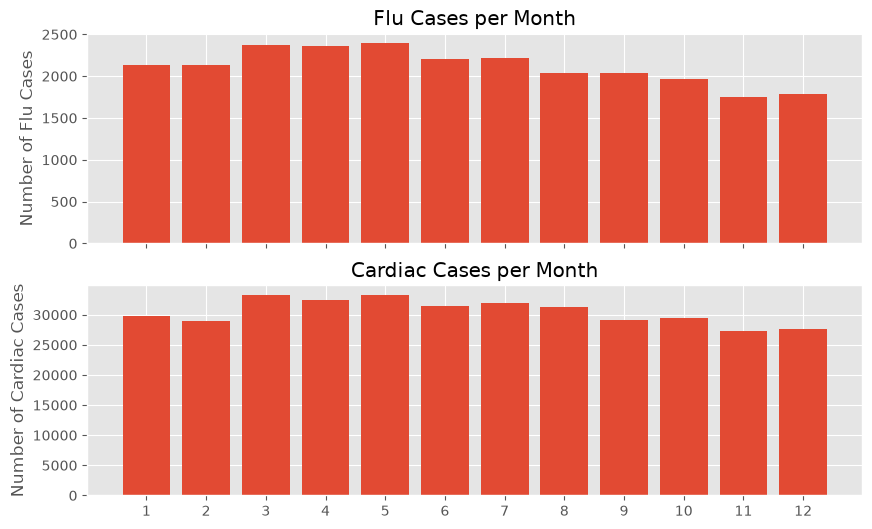

In [30]:
fig, ax = plt.subplots(2, 1, figsize = (10, 6), sharex=True)

df_dict = {'flu': flu_df_deduped,
          'cardiac': cardiac_df_deduped,
           }

i = 0
for name, df in df_dict.items():

  month_order = df['condition_start_date_month'].value_counts().sort_index().reset_index()

  ax[i].bar(month_order['condition_start_date_month'], month_order['count'])
  ax[i].set_xticks(np.arange(1, 13, 1))
  ax[i].set_label("Month")
  ax[i].set_ylabel(f"Number of {name.title()} Cases")
  ax[i].set_title(f"{name.title()} Cases per Month")

  i += 1

plt.show()

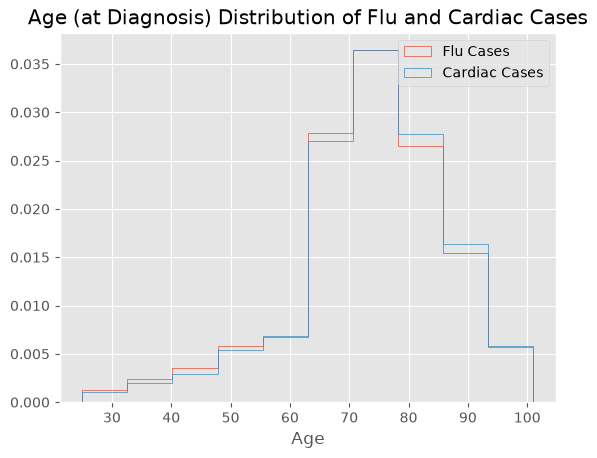

In [31]:
plt.hist(flu_df_deduped['age_at_diagnosis'], density=True, histtype='step', label='Flu Cases')
plt.hist(cardiac_df_deduped['age_at_diagnosis'], density=True, histtype='step', label='Cardiac Cases')

plt.title("Age (at Diagnosis) Distribution of Flu and Cardiac Cases")
plt.xlabel("Age")

plt.legend()
plt.show()

In [ ]:
### join frequency data of flu - how many times did each person get sick - look at relationships
flu_counts = flu_df_deduped.value_counts('person_id').reset_index()
flu_counts = flu_counts.rename(columns={'count': 'flu_cases'})

## to prevent double merge
if 'flu_cases' not in flu_df_deduped.columns:
  flu_df_deduped = flu_df_deduped.merge(flu_counts, how='outer', on = 'person_id')

assert (flu_df_deduped['flu_cases'] > 0).all(), 'Zero flu cases are found in the data'

In [ ]:
### join frequency data of cardiac - how many times did each person have an incident - look at relationships
cardiac_counts = cardiac_df_deduped.value_counts('person_id').reset_index()
cardiac_counts = cardiac_counts.rename(columns={'count': 'cardiac_cases'})

## to prevent double merge
if 'cardiac_counts' not in cardiac_df_deduped.columns:
  cardiac_df_deduped = cardiac_df_deduped.merge(cardiac_counts, how='outer', on = 'person_id')

assert (cardiac_df_deduped['cardiac_cases'] > 0).all(), 'Zero cardiac cases are found in the data'

### Patients Diagnosed with Both Flu AND Cardiac Events

By joining on the level of the person, the dataframe can explode into many records for a single event. (i.e. A patient with 5 heart attacks and 1 flu case will have 5 'flu' cases when joined to the other table.). Prior to graphing or calculations these will be accounted for. 

In [34]:
flu_cardiac_inner_joined = flu_df_deduped.merge(cardiac_df_deduped, how='inner', on='person_id', suffixes=('_flu', '_cardiac'))
flu_cardiac_inner_joined['flu_cardiac_time_delta'] = flu_cardiac_inner_joined['condition_end_date_cardiac'] - flu_cardiac_inner_joined['condition_end_date_flu']
flu_cardiac_inner_joined['flu_cardiac_time_delta_int'] = pd.to_timedelta(flu_cardiac_inner_joined['flu_cardiac_time_delta']).dt.days

print(f"""Number of records in the dataframe: {len(flu_cardiac_inner_joined):,}\n""")
print(f"""Number of unique people who have had both cardiac problems and the flu: {len(flu_cardiac_inner_joined['person_id'].unique()):,}\n""")
flu_cardiac_inner_joined.head()

Number of records in the dataframe: 8,636

Number of unique people who have had both cardiac problems and the flu: 6,316



,person_id,ancestor_concept_id_flu,ancestor_concept_flu,concept_search_code_flu,ancestor_concept_id_1_flu,descendant_concept_id_flu,min_levels_of_separation_flu,max_levels_of_separation_flu,condition_occurrence_id_flu,condition_concept_id_flu,...,year_of_birth_cardiac,month_of_birth_cardiac,day_of_birth_cardiac,age_at_diagnosis_cardiac,gender_label_cardiac,ethnicity_label_cardiac,condition_label_cardiac,cardiac_cases,flu_cardiac_time_delta,flu_cardiac_time_delta_int
0,1164,4266367,Influenza,6142004,4266367,256723,1,1,149536,256723,...,1940,4,1,69,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of inferoposterior...,1,348 days,348
1,2400,4266367,Influenza,6142004,4266367,256723,1,1,303497,256723,...,1932,8,1,76,FEMALE,Not Hispanic or Latino,Acute myocardial infarction,1,65 days,65
2,2464,4266367,Influenza,6142004,4266367,314979,2,2,309635,314979,...,1917,10,1,91,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of anterolateral wall,2,-357 days,-357
3,2464,4266367,Influenza,6142004,4266367,314979,2,2,309635,314979,...,1917,10,1,92,FEMALE,Not Hispanic or Latino,Acute myocardial infarction of inferior wall,2,105 days,105
4,3374,4266367,Influenza,6142004,4266367,314979,2,2,427243,314979,...,1929,1,1,80,MALE,Not Hispanic or Latino,Acute myocardial infarction of inferoposterior...,2,377 days,377


### Patients Suffering from Cardiac Events OR has been vaccinated.

Outer join - every vaccination gets paired with every cardiac event. Enables us to compare time between events.

In [35]:
### create df of people who have had a vaccine AND / OR cadiac event
cardiac_vaccine_joined = cardiac_df_deduped.merge(flu_vaccine_deduped, how='outer', on='person_id')
cardiac_vaccine_joined['ever_vaccinated'] = np.where(cardiac_vaccine_joined['drug_exposure_start_date'].isnull(),
                                                    False,
                                                    True)

## calculate how much time from vaccination to cardiac event
cardiac_vaccine_joined['vaccine_time_to_cardiac'] = cardiac_vaccine_joined['drug_exposure_start_date'] - cardiac_vaccine_joined['condition_start_date']
cardiac_vaccine_joined['cardiac_cases'] = cardiac_vaccine_joined['cardiac_cases'].fillna(0)

### outer joined - so not all individuals have cardiac problems and not all individuals have vaccines
### they have had at least one if not both

In [36]:
### we know the df is not deduplicated by people right now - so deduplicate in code
vaccination_rate = pd.DataFrame(cardiac_vaccine_joined.drop_duplicates(subset=['person_id'])['ever_vaccinated'].value_counts())
vaccination_rate['percentage'] = np.round(vaccination_rate['count'] / vaccination_rate['count'].sum() * 100, 2)
vaccination_rate

,count,percentage
ever_vaccinated,,
True,977094,88.82
False,122983,11.18


In [37]:
## add the column counting number of vaccinations for a given person
cardiac_vaccine_joined = cardiac_vaccine_joined.merge(times_vaccinated, how='left', on = 'person_id')
cardiac_vaccine_joined['times_flu_vaccinated'] = cardiac_vaccine_joined['times_flu_vaccinated'].fillna(0).astype(int)
cardiac_vaccine_joined['cardiac_cases'] = cardiac_vaccine_joined['cardiac_cases'].fillna(0).astype(int)

In [38]:
### deduplicate. Should now tell us how many cardiac events and flu vaccines a person has had
cardiac_vaccine_people_deduped = cardiac_vaccine_joined[['person_id', 'cardiac_cases', 'times_flu_vaccinated']].drop_duplicates()

assert cardiac_vaccine_people_deduped['person_id'].nunique() == len(cardiac_vaccine_people_deduped), 'DF not deduplicated'

### Individuals have had at least one cardiac event and one vaccination
Notice no records have zero for both flu and cardiac cases

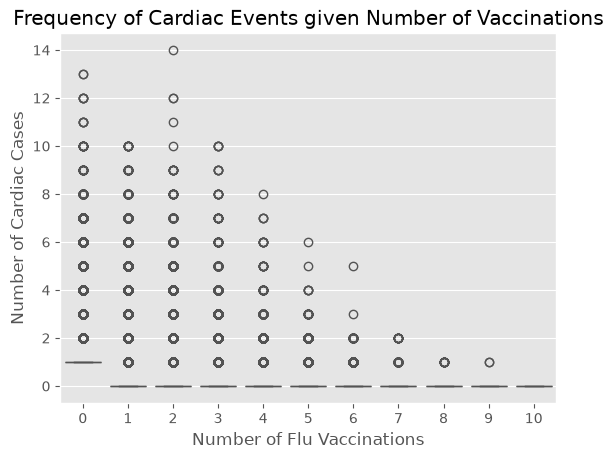

In [39]:
sns.boxplot(data=cardiac_vaccine_people_deduped, x='times_flu_vaccinated', y='cardiac_cases')
plt.title("Frequency of Cardiac Events given Number of Vaccinations")
plt.ylabel("Number of Cardiac Cases")
plt.xlabel("Number of Flu Vaccinations")
plt.show()

People who have never had a vaccine AND have never had a heart attack, you are not included in this graph.

In [40]:
cardiac_vaccine_joined['vaccine_time_to_cardiac_int'] = pd.to_timedelta(cardiac_vaccine_joined['vaccine_time_to_cardiac']).dt.days

cardiac_after_vaccine = cardiac_vaccine_joined[cardiac_vaccine_joined['vaccine_time_to_cardiac_int'] >= 0]
# cardiac_after_vaccine = cardiac_after_vaccine.sort_values(by='vaccine_time_to_cardiac_int').drop_duplicates(subset=['person_id'])

In [41]:
# # for each person a single flu shot can be compared against multiple heart attacks
# # for each person a single heart attack can be compared to multiple flu shots
# # determine by looking at duplicate condition_occurrence_id and drug_exposure_id
# cardiac_after_vaccine['vaccine_time_to_cardiac_int'].hist(bins=100)
# plt.title("Time to Cardiac Event after Flu Vaccination\n(Persons not Deduplicated)")
# plt.xlabel("Days")
# plt.ylabel("Vaccination x Cardiac Pairs")
# plt.show()

In [ ]:
### considering only each individual person - what was the shortest delta between having the flu and a cardiac event
### used for survival curve
closest_distance = flu_cardiac_inner_joined[flu_cardiac_inner_joined['flu_cardiac_time_delta_int'] >= 0]
closest_distance = closest_distance.sort_values(by=['flu_cardiac_time_delta_int']).drop_duplicates(subset='person_id')
closest_distance['ever_vaccinated'] = closest_distance['person_id'].isin(flu_vaccine_deduped['person_id'])

In [ ]:
### not used - plot commented out

# cardiac_flu_outer_joined = cardiac_df_deduped.merge(flu_df_deduped, how='outer', on='person_id', suffixes=('_cardiac', '_flu'))

# cardiac_flu_outer_joined['flu_cardiac_time_delta'] = cardiac_flu_outer_joined['condition_end_date_cardiac'] - cardiac_flu_outer_joined['condition_end_date_flu']
# cardiac_flu_outer_joined['flu_cardiac_time_delta_int'] = pd.to_timedelta(cardiac_flu_outer_joined['flu_cardiac_time_delta']).dt.days

# cardiac_flu_outer_joined['ever_vaccinated'] = cardiac_flu_outer_joined['person_id'].isin(flu_vaccine_deduped['person_id'])

In [44]:
# no_vaccine_yes_flu_cardiac = cardiac_flu_outer_joined[cardiac_flu_outer_joined['ever_vaccinated']==False]
# no_vaccine_yes_flu_cardiac = no_vaccine_yes_flu_cardiac[no_vaccine_yes_flu_cardiac['cardiac_cases'] > 0]
# no_vaccine_yes_flu_cardiac = no_vaccine_yes_flu_cardiac[no_vaccine_yes_flu_cardiac['flu_cases'] > 0]
# no_vaccine_yes_flu_cardiac_after = no_vaccine_yes_flu_cardiac[no_vaccine_yes_flu_cardiac['flu_cardiac_time_delta_int'] >= 0]

# no_vaccine_yes_flu_cardiac_after = no_vaccine_yes_flu_cardiac_after.sort_values(by=['flu_cardiac_time_delta_int']).drop_duplicates(subset='person_id')

The flu elicits an inflammatory response, and in general, being sick can lead to further problems. Is there a potential protective effect of the vaccine on flu -> cardiac event? Potentially by making the flu less severe, therefore leading to less complications later?

In [45]:
never_vaccinated = closest_distance[~closest_distance['ever_vaccinated']]
yes_vaccinated = closest_distance[closest_distance['ever_vaccinated']]

print(f"Unvaccinated patients: {len(never_vaccinated):,}")
print(f"Vaccinated patients: {len(yes_vaccinated):,}")

# plt.hist(never_vaccinated['flu_cardiac_time_delta_int'], density=True, label='Never Vaccinated', alpha = 0.5)
# plt.hist(yes_vaccinated['flu_cardiac_time_delta_int'], density=True, label='Vaccinated', alpha = 0.5)
# plt.title("Time Between Flu and Cardiac Event Given Vaccination Status", size=12)
# plt.xlabel("Days")
# plt.ylabel("Density")
# plt.legend()
# plt.show()

Unvaccinated patients: 1,585
Vaccinated patients: 2,147


### Survival Curve 
How long does it take for patients to suffer from a cardiac event after the flu, based on their vaccination status.

In [46]:
step_points = np.arange(0, closest_distance['flu_cardiac_time_delta_int'].max()+1, 50)

survival_vac = []
survival_no_vac = []

num_unvaccinated = len(never_vaccinated)
num_vaccinated = len(yes_vaccinated)

for point in step_points:

    num_vacc_less_than = len(yes_vaccinated[yes_vaccinated['flu_cardiac_time_delta_int']>=point])
    num_no_vacc_less_than = len(never_vaccinated[never_vaccinated['flu_cardiac_time_delta_int']>=point])

    survival_vac.append(num_vacc_less_than / num_vaccinated)
    survival_no_vac.append(num_no_vacc_less_than / num_unvaccinated)

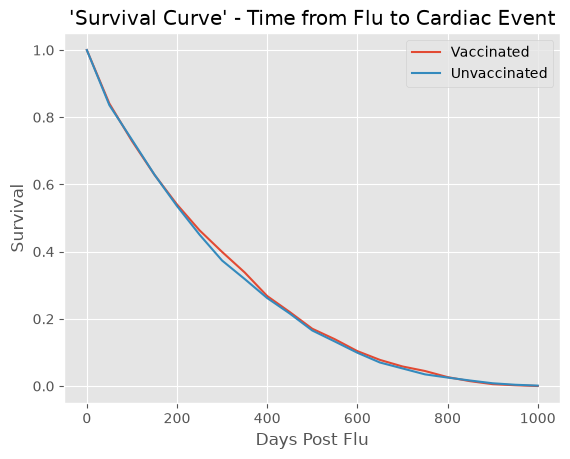

In [47]:
plt.plot(step_points, survival_vac, label = 'Vaccinated')
plt.plot(step_points,survival_no_vac, label = 'Unvaccinated')

plt.ylabel("Survival")
plt.xlabel("Days Post Flu")
plt.title("'Survival Curve' - Time from Flu to Cardiac Event")
plt.legend()
plt.show()

#### The following plot suggests an inverse relationship with having the flu and greater numbers of cardiac events. Given the sample size for the value counts (shown in the table below the plot), I wouldn't consider it a robust enough sample to inform any relationship between the flu and cardiac events. However I'm keeping in the notebook for reference.

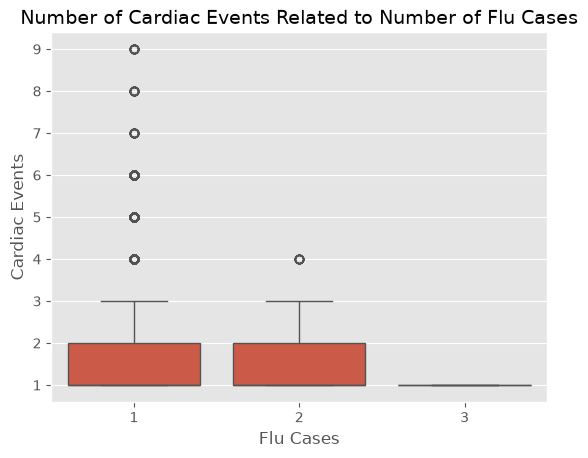

In [48]:
sns.boxplot(data = flu_cardiac_inner_joined[['flu_cases', 'cardiac_cases']],
            x = 'flu_cases',
            y='cardiac_cases')

plt.ylabel("Cardiac Events")
plt.xlabel("Flu Cases")
plt.title("Number of Cardiac Events Related to Number of Flu Cases", size=14)
plt.show()

In [49]:
pd.DataFrame(flu_cardiac_inner_joined.groupby(['flu_cases'])['cardiac_cases'].value_counts())

count
flu_cases cardiac_cases       
1         1               4736
          2               2122
          3                870
          4                296
          5                175
          6                144
          8                 24
          7                 21
          9                 18
2         1                136
          2                 48
          3                 24
          4                 16
3         1                  6

## Next Steps / Analysis Ideas:

Aggregate all data from the first 18 months of the window. Predict likelihood of a cardiac event in the last 6 months of the dataset.
Key features:

* How many heart attacks have already happened
* How many times have they had the flu
* Have they been vaccinated for the flu
* Do they have diabetes
* Age at prediction (last 6 months)

--- 
Survival analysis:
* The survival plot above shows if the person was "ever" vaccinated. Could improve this by taking records of people who have only been vaccinated within at most 6 months prior to getting the flu.

* Flu severity could be assesed through the concepts. There are concepts that suggest inpatient hospitalization.
* Other's would be useful for heart attack severity / complication investigation.

---

## Scratch Code / Documentation Below

#### Additional Thoughts / Points:
* For those that received the flu vaccine vs not
    * What is the rate of getting the flu in the next 7 months
    * What is the rate of having a cardiac event in the next seven months

* For those that had a heart attack vs not:
    * how many had the flu in the past seven months 

* How does diabetes play a role?

### Conditional Probabilities

Irrespective of time or number of cases, how connected are flu diagnoses and cardiac problems. Very basic question, but can be interesting in specific circumstances.

In [ ]:
## get total number of people
query = """
        SELECT COUNT(DISTINCT(`person_id`)) as `num_total_people`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.person`
        ;"""

unique_people_df = CLIENT.query(query).to_dataframe()
display(unique_people_df)

unique_people = unique_people_df['num_total_people'].iloc[0]

In [ ]:
w_cardiac = cardiac_df['person_id'].nunique() / unique_people
w_flu = flu_df['person_id'].nunique() / unique_people
w_both = flu_cardiac_inner_joined['person_id'].nunique() / unique_people
if_independent = w_cardiac * w_flu

print(f"Proportion of people suffered from cardiac events: {np.round(w_cardiac, 3):,}")
print(f"Proportion of people diagnosed with the flu: {np.round(w_flu, 3):,}")


If we were to assume that the diagnosis of the flu and cardiac events are completely independent, we would expect that the number of people who have both cases to be the rate of each multiplied by each other

In [ ]:

print(f"""Assumming statistical independence, the ratio of people with both flu and suffered cardiac events:""")
print(f"{np.round(if_independent, 4)}")
print("---")
print(f"The actual prevalence of individuals who have been diagnosed with both the flu and suffered cardiac events")
print(f"{np.round(w_both, 4)}")

print(f"""
Ratio of actual vs expected: {np.round(w_both / if_independent, 3)}
""")

In a real life scenario, is this informative? Potentially, but too simplistic for any real insight.